In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.io import arff

In [3]:
# Read the ARFF file manually (it was saved as df.md but the content is ARFF format)
with open('../data/raw/Rice_Cammeo_Osmancik.arff', 'r') as f:
    lines = f.readlines()

# Column names, in the order they appear in @ATTRIBUTE lines
columns = ['Area', 'Perimeter', 'Major_Axis_Length', 'Minor_Axis_Length',
           'Eccentricity', 'Convex_Area', 'Extent', 'Class']

# Find where the actual data starts (after the @DATA line)
data_start = next(i for i, l in enumerate(lines) if l.strip().upper() == '@DATA') + 1
data_lines = [l.strip() for l in lines[data_start:] if l.strip()]

# Parse into a DataFrame
rows = [l.split(',') for l in data_lines]
df = pd.DataFrame(rows, columns=columns)

# Convert numeric columns from text to actual numbers
num_cols = columns[:-1]
df[num_cols] = df[num_cols].astype(float)

# Save a clean CSV for every other notebook to reuse
df.to_csv('../data/raw/rice.csv', index=False)

print(df.shape)
df.head()

(3810, 8)


,Area,Perimeter,Major_Axis_Length,Minor_Axis_Length,Eccentricity,Convex_Area,Extent,Class
0,15231.0,525.578979,229.749878,85.093788,0.928882,15617.0,0.572896,Cammeo
1,14656.0,494.311005,206.020065,91.730972,0.895405,15072.0,0.615436,Cammeo
2,14634.0,501.122009,214.106781,87.768288,0.912118,14954.0,0.693259,Cammeo
3,13176.0,458.342987,193.337387,87.448395,0.891861,13368.0,0.640669,Cammeo
4,14688.0,507.166992,211.743378,89.312454,0.906691,15262.0,0.646024,Cammeo


In [4]:
print("--- Dataset Shape ---")
print(f"Total Rows (Instances): {df.shape[0]}")
print(f"Total Columns (Attributes): {df.shape[1]}")

print("\n--- Data Types & Missing Values ---")
print(df.info())

print("\n--- Target Variable Distribution ---")
print(df['Class'].value_counts())
print("\nTarget Class Percentage:")
print(df['Class'].value_counts(normalize=True) * 100)

--- Dataset Shape ---
Total Rows (Instances): 3810
Total Columns (Attributes): 8

--- Data Types & Missing Values ---
<class 'pandas.DataFrame'>
RangeIndex: 3810 entries, 0 to 3809
Data columns (total 8 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Area               3810 non-null   float64
 1   Perimeter          3810 non-null   float64
 2   Major_Axis_Length  3810 non-null   float64
 3   Minor_Axis_Length  3810 non-null   float64
 4   Eccentricity       3810 non-null   float64
 5   Convex_Area        3810 non-null   float64
 6   Extent             3810 non-null   float64
 7   Class              3810 non-null   str    
dtypes: float64(7), str(1)
memory usage: 238.3 KB
None

--- Target Variable Distribution ---
Class
Osmancik    2180
Cammeo      1630
Name: count, dtype: int64

Target Class Percentage:
Class
Osmancik    57.217848
Cammeo      42.782152
Name: proportion, dtype: float64


C:\Users\ADMIN\AppData\Local\Temp\ipykernel_26788\788678382.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='Class', palette='Set2')


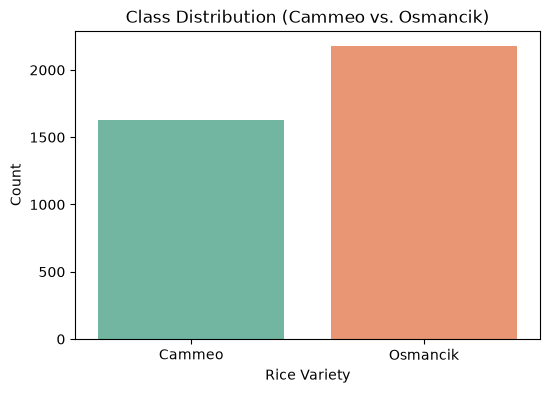

In [5]:
# Distribution of the Target Class
plt.figure(figsize=(6, 4))
sns.countplot(data=df, x='Class', palette='Set2')
plt.title('Class Distribution (Cammeo vs. Osmancik)')
plt.xlabel('Rice Variety')
plt.ylabel('Count')
plt.show()

In [6]:
print("\n--- Summary Statistics ---")
print(df.describe().T[['mean', 'std', 'min', '50%', 'max']])


--- Summary Statistics ---
                           mean          std          min           50%  \
Area               12667.727559  1732.367706  7551.000000  12421.500000   
Perimeter            454.239180    35.597081   359.100006    448.852493   
Major_Axis_Length    188.776222    17.448679   145.264465    185.810059   
Minor_Axis_Length     86.313750     5.729817    59.532406     86.434647   
Eccentricity           0.886871     0.020818     0.777233      0.889050   
Convex_Area        12952.496850  1776.972042  7723.000000  12706.500000   
Extent                 0.661934     0.077239     0.497413      0.645361   

                            max  
Area               18913.000000  
Perimeter            548.445984  
Major_Axis_Length    239.010498  
Minor_Axis_Length    107.542450  
Eccentricity           0.948007  
Convex_Area        19099.000000  
Extent                 0.861050  


In [8]:
import pandas as pd

# Load dataset
df = pd.read_csv('../data/raw/rice.csv')

# 1. Verify initial state
print(df[["Minor_Axis_Length", "Eccentricity"]].isnull().sum())

# 2. Impute missing values with Median
df["Minor_Axis_Length"].fillna(
    df["Minor_Axis_Length"].median(), inplace=True
)
df["Eccentricity"].fillna(df["Eccentricity"].median(), inplace=True)

# 3. Verify final state
print(df[["Minor_Axis_Length", "Eccentricity"]].isnull().sum())

Minor_Axis_Length    0
Eccentricity         0
dtype: int64
Minor_Axis_Length    0
Eccentricity         0
dtype: int64


C:\Users\ADMIN\AppData\Local\Temp\ipykernel_26788\990417919.py:10: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through chained assignment using an inplace method.
Such inplace method never works to update the original DataFrame or Series, because the intermediate object on which we are setting values always behaves as a copy (due to Copy-on-Write).

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' instead, to perform the operation inplace on the original object, or try to avoid an inplace operation using 'df[col] = df[col].method(value)'.

See the documentation for a more detailed explanation: https://pandas.pydata.org/pandas-docs/stable/user_guide/copy_on_write.html
  df["Minor_Axis_Length"].fillna(
C:\Users\ADMIN\AppData\Local\Temp\ipykernel_26788\990417919.py:13: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through chained assignment using an inplace

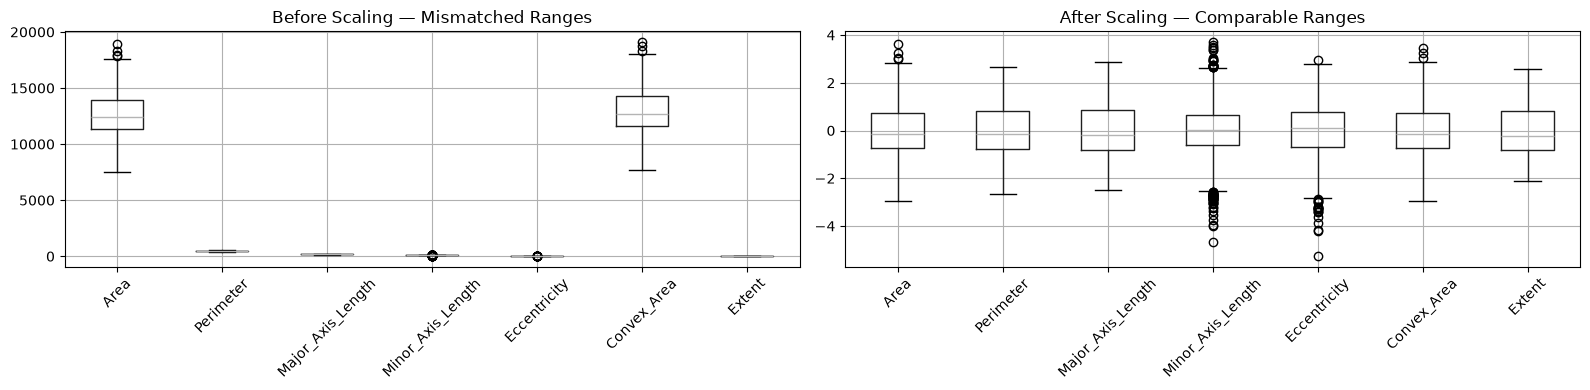

In [10]:
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.preprocessing import StandardScaler

# 1. Load your dataset

df = pd.read_csv('../data/raw/rice.csv')
# 2. Separate numerical features (exclude non-numerical target column like 'Class')
features = df.select_dtypes(include=["float64", "int64"]).columns
X = df[features]

# 3. Apply Feature Scaling (StandardScaler)
scaler = StandardScaler()
X_scaled = pd.DataFrame(scaler.fit_transform(X), columns=features)

# 4. Create side-by-side boxplots
fig, axes = plt.subplots(1, 2, figsize=(16, 4))

# Left Plot: Before Scaling
X.boxplot(ax=axes[0], rot=45)
axes[0].set_title("Before Scaling — Mismatched Ranges")

# Right Plot: After Scaling
X_scaled.boxplot(ax=axes[1], rot=45)
axes[1].set_title("After Scaling — Comparable Ranges")

plt.tight_layout()
plt.show()

C:\Users\ADMIN\AppData\Local\Temp\ipykernel_26788\2186092205.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='Class', y=feature, palette='Set2')
C:\Users\ADMIN\AppData\Local\Temp\ipykernel_26788\2186092205.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='Class', y=feature, palette='Set2')
C:\Users\ADMIN\AppData\Local\Temp\ipykernel_26788\2186092205.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='Class', y=feature, palette='Set2')
C:\Users\ADMIN\AppData\Local\Temp\ipykernel_26788\2186092205.py:5: 

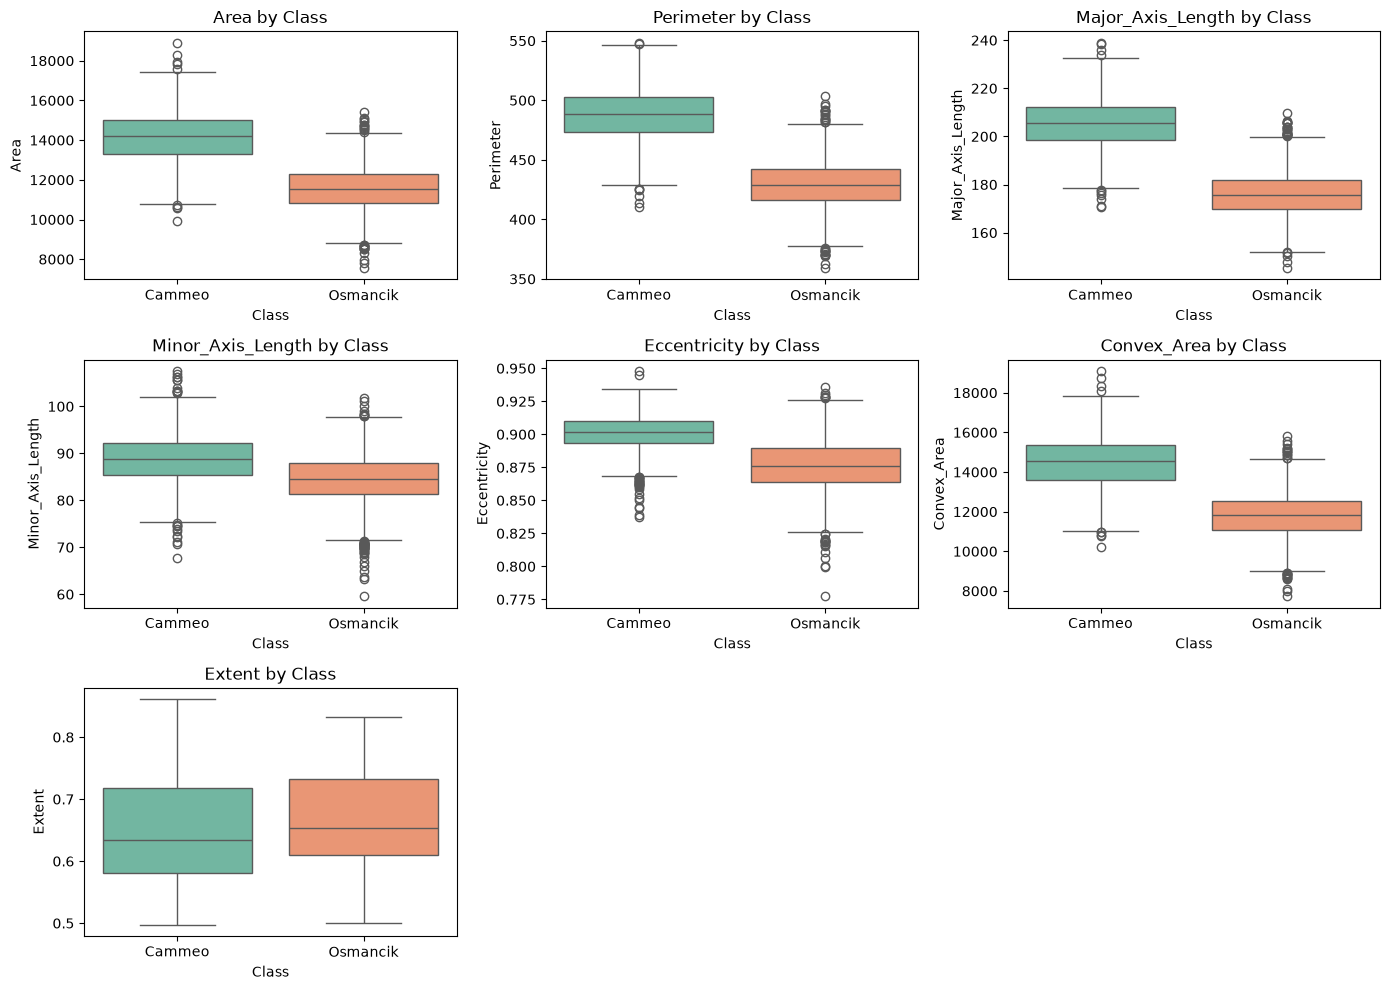

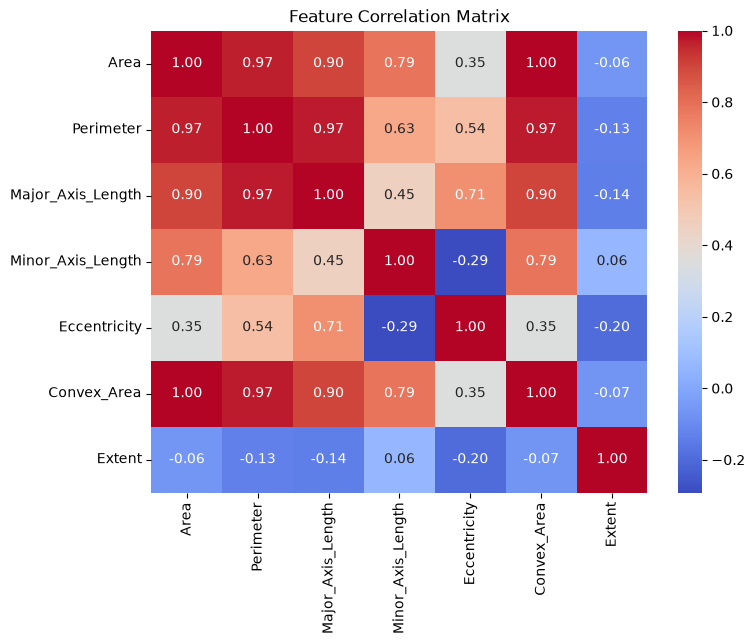

In [11]:
features = ['Area', 'Perimeter', 'Major_Axis_Length', 'Minor_Axis_Length', 'Eccentricity', 'Convex_Area', 'Extent']
plt.figure(figsize=(14, 10))
for i, feature in enumerate(features, 1):
    plt.subplot(3, 3, i)
    sns.boxplot(data=df, x='Class', y=feature, palette='Set2')
    plt.title(f'{feature} by Class')
plt.tight_layout()
plt.show()

# Correlation Matrix of Numerical Features
plt.figure(figsize=(8, 6))
sns.heatmap(df.drop(columns=['Class']).corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Feature Correlation Matrix')
plt.show()

NameError: name 'df_clean' is not defined

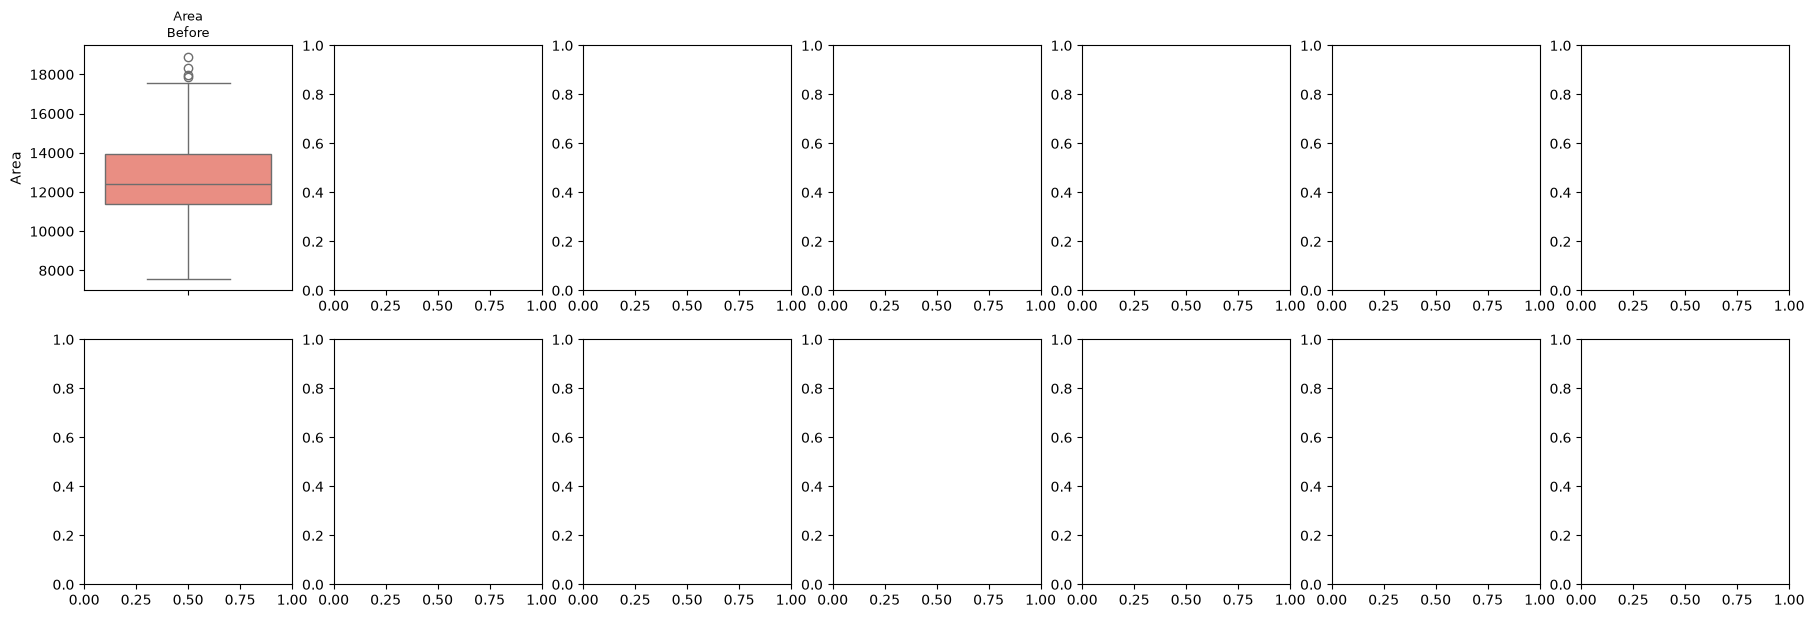

In [12]:
import matplotlib.pyplot as plt
import seaborn as sns

num_cols = df.columns[:-1]   # all 7 features
fig, axes = plt.subplots(2, 7, figsize=(22, 7))
for i, col in enumerate(num_cols):
    sns.boxplot(y=df[col], ax=axes[0, i], color='salmon')
    axes[0, i].set_title(f'{col}\nBefore', fontsize=9)
    sns.boxplot(y=df_clean[col], ax=axes[1, i], color='lightgreen')
    axes[1, i].set_title('After', fontsize=9)
plt.tight_layout()
plt.savefig('all_features_outliers_before_after.png', dpi=150)
plt.show()